In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
from tensorflow.keras.models import Model
import pandas as pd
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras import backend as keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Recall
from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
import seaborn as sns
import time

# 繪圖

In [2]:
def plot_CM(true_label, pred_label, title = ' '):
    
    # Creates a confusion matrix
    cm = confusion_matrix(true_label, pred_label) 
    cm[0, 0], cm[1, 1] = cm[1, 1], cm[0, 0]
    # Transform to df for easier plotting
    cm_df = pd.DataFrame(cm,
                         index = ['Positive', 'Negative'], 
                         columns = ['Positive', 'Negative'])

    plt.figure(figsize=(5.5,4))
    sns.heatmap(cm_df, annot=True, fmt="d")

    plt.title(title )
    plt.ylabel('Predicted label')
    plt.xlabel('True label')
    plt.show()

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
cfg = tf.compat.v1.ConfigProto() 
cfg.gpu_options.visible_device_list="0"
cfg.gpu_options.allow_growth=True
cfg.gpu_options.per_process_gpu_memory_fraction = 0.7# 使用50%的GPU暫存  
session = tf.compat.v1.Session(config=cfg )

# GPU調整

In [4]:
def solve_cudnn_error():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.experimental.list_logical_devices('GPU')
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)

# 有無膽囊分類

In [5]:
def test_predict_load_image(test_file, target_size=(224,224)):
    img = cv2.imread(test_file, cv2.IMREAD_COLOR)
    img_size=np.zeros([512,512,3],dtype="uint8")
    img_size[51:461,51:461,:]=img[51:461,51:461,:]
    img = img_size / 255
    img = cv2.resize(img, target_size)
    img = np.reshape(img,(1,) + img.shape)
    

    return img

In [6]:
def test_predict_generator(test_files, test_data_folder,target_size=(224,224)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_predict_load_image(test_file, target_size)

In [7]:
def test_load_image(test_file, target_size=(512,512)):
    img = cv2.imread(test_file, cv2.IMREAD_GRAYSCALE)
    img_size=np.zeros([512,512],dtype="uint8")
    gaussian_blur = cv2.bilateralFilter(img,15,75,75)
    img_size[51:461,51:461]=gaussian_blur[51:461,51:461]
    img = img_size / 255
    img = cv2.resize(img, target_size)
    img = np.reshape(img, img.shape + (1,))
    img = np.reshape(img,(1,) + img.shape)
    return img

def test_generator(test_files,test_data_folder , target_size=(512,512)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_load_image(test_file, target_size)
        
def save_result(save_path, npyfile, test_files):
    for i, item in enumerate(npyfile):
        result_file = test_files[i]
        img = (item[:, :, 0] * 255.).astype(np.uint8)

        result_file = os.path.join(save_path, result_file)

        cv2.imwrite(result_file, img)

In [8]:
def test_load_image2(test_file,mask_file, target_size=(512,512)):
    img = cv2.imread(test_file, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    ret, mask_out = cv2.threshold(mask, 200, 255, cv2.THRESH_BINARY)
    DILATE_KERNEL = np.ones((9, 9), np.uint8)
    mask_open = cv2.morphologyEx(mask_out, cv2.MORPH_OPEN, DILATE_KERNEL, iterations=2)
    new_img = np.zeros_like(img)
    new_img[mask_open > 240] = img[mask_open > 240]
    new_img = new_img / 255
    new_img = cv2.resize(new_img, target_size)
    new_img = np.reshape(new_img, new_img.shape + (1,))
    new_img = np.reshape(new_img,(1,) + new_img.shape)
    return new_img

def test_generator2(test_files,test_data_folder ,mask_folder, target_size=(512,512)):
    for test_img in test_files:
        test_file=os.path.join(test_data_folder,test_img)
        mask_file=os.path.join(mask_folder,test_img)
        yield test_load_image2(test_file,mask_file, target_size)
        
def save_result2(save_path, npyfile, test_files):
    for i, item in enumerate(npyfile):
        result_file = test_files[i]
        img = (item[:, :, 0] * 255.).astype(np.uint8)

        result_file = os.path.join(save_path, result_file)

        cv2.imwrite(result_file, img)

In [25]:
def segment_post_processing(segment_dir,test_case_dir,segment_file,test_image_dir):
    kernel = np.ones((15, 15), np.uint8)
    A_file=np.zeros((100,100), np.uint8)
    B_file=np.zeros((100,100), np.uint8)
    num=1
    case_img_list=[]
    case_c_point_list=[]
    file_list_name=[]
    for file_num in range (0,len(segment_file)):
        
        B_file=cv2.imread(segment_dir+"/{}".format(segment_file[file_num]))
        #B_file_gray = cv2.cvtColor(B_file, cv2.COLOR_BGR2GRAY)
        
        if A_file.shape==B_file.shape:
            A_file_open = cv2.morphologyEx(A_file, cv2.MORPH_OPEN, kernel,iterations=1)
            A_file_open_gray = cv2.cvtColor(A_file_open, cv2.COLOR_BGR2GRAY)
            ret, A_file_open_gray = cv2.threshold(A_file_open_gray, 40, 255, cv2.THRESH_BINARY)
            B_file_open = cv2.morphologyEx(B_file, cv2.MORPH_OPEN, kernel,iterations=1)
            B_file_open_gray = cv2.cvtColor(B_file_open, cv2.COLOR_BGR2GRAY)
            ret, B_file_open_gray = cv2.threshold(B_file_open_gray, 40, 255, cv2.THRESH_BINARY)
            two_img_mask = cv2.bitwise_and(A_file_open_gray, B_file_open_gray)
            contours, hierarchy = cv2.findContours(two_img_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            contour_output=A_file_open.copy()
            output=cv2.drawContours(contour_output, contours, -1, (0, 0, 255), 2)
            if len(contours)!= 0:
                contour_num=1
                img_list=[]
                ROI_list=[]
                c_point_list=[]
                for contour in contours:
                    seedpoint_x=0
                    seedpoint_y=0
                    for point in contour:
                        seedpoint_x=seedpoint_x+point[0][0]
                        seedpoint_y=seedpoint_y+point[0][1]      
                    seedpoint=(round(seedpoint_x/len(contour)),round(seedpoint_y/len(contour)))
                    h, w = A_file.shape[:2]
                    ROI = np.zeros((h,w,3), np.uint8)
                    ret, img = cv2.threshold(A_file, 40, 255, cv2.THRESH_BINARY)
                    mask = np.zeros((h+2,w+2,1), np.uint8)
                    cv2.floodFill(img, mask,seedpoint, (0,0,255),(20,20,20),(20,20,20))
                    lower_color = np.array([0, 0, 220])
                    upper_color = np.array([0, 0, 255])
                    ROI = cv2.inRange(img, lower_color, upper_color)
                    if contour_num ==1:
                        index_list=np.argwhere(ROI[:,:]>=240)
                        cx=0
                        cy=0
                        for i in index_list:
                            cx=cx+i[0]
                            cy=cy+i[1]
                        c_point=(round(cy/len(index_list)),round(cx/len(index_list)))
                        if c_point not in c_point_list:
                            img_list.append(img)
                            ROI_list.append(ROI)
                            c_point_list.append(c_point)
                    else:
                        if True in (img != img_list[-1]):
                            index_list=np.argwhere(ROI[:,:]>=240)
                            cx=0
                            cy=0
                            for i in index_list:
                                cx=cx+i[0]
                                cy=cy+i[1]
                            c_point=(round(cy/len(index_list)),round(cx/len(index_list)))
                            if c_point not in c_point_list:
                                img_list.append(img)
                                ROI_list.append(ROI)
                                c_point_list.append(c_point)
                    contour_num=1+contour_num
                case_img_list.append(ROI_list)
                case_c_point_list.append(c_point_list)
                file_list_name.append(segment_file[file_num-1])
            num=num+1
        A_file=B_file
    big_list=[]
    mid_point_num=round(len(case_c_point_list)/2)
    time=0
    
    for point in case_c_point_list[mid_point_num]:
        top_point=True
        bottom_point=True
        small_list=[point]
        for i in range(1,len(case_c_point_list)-mid_point_num):
            if top_point:
                for point_up in case_c_point_list[mid_point_num-i]:
                    if i==1:
                        distance=np.sum(abs(np.array(point_up)-np.array(point)))
                    else:
                        distance=np.sum(abs(np.array(point_up)-np.array(new_point_up)))
                    #print(distance)
                    if distance<70:
                        small_list.append(point_up)
                        new_point_up=point_up
                        top_point=True
                        break
                    else:
                        top_point=False
                        
            if bottom_point:        
                for point_down in case_c_point_list[mid_point_num+i]:
                    if i==1:
                        distance=np.sum(abs(np.array(point_down)-np.array(point)))
                    else:
                        distance=np.sum(abs(np.array(point_down)-np.array(new_point_down)))
                
                    if distance<70:
                        small_list.append(point_down)
                        new_point_down=point_down
                        bottom_point=True
                        break
                    else:
                        bottom_point=False
        big_list.append(small_list)
        
        
    position=[]
    condition=0
    for one_object in big_list:
        if len(one_object)>condition:
            condition=len(one_object)
            gallbladder=one_object
    for a in gallbladder:
        i=0
        for point in case_c_point_list:
            try:
                c=point.index(a)
                position.append([i,c])
            except ValueError:
                pass
            i+=1
    position.sort()
    gallbladder_dir=os.path.join(test_case_dir,"mask") 
    try:
        os.mkdir(gallbladder_dir)
    except:
        pass
    return_imgname=[]
    kernel1 = np.ones((3,3), np.uint8)
    for i in position:
        #original = cv2.imread(os.path.join(test_image_dir,file_list_name[i[0]]))
        ret, mask_out = cv2.threshold(case_img_list[i[0]][i[1]], 200, 255, cv2.THRESH_BINARY)
        #edges = cv2.Canny(mask_out, 10, 200)
        #original[edges > 240] = (0,0,255)
        mask_out = cv2.morphologyEx(mask_out, cv2.MORPH_OPEN, kernel1) 
        #mask_out = cv2.erode(mask_out, kernel1)
        cv2.imwrite(gallbladder_dir+"/{}".format(file_list_name[i[0]]),mask_out)
        return_imgname.append(file_list_name[i[0]])
    return return_imgname,gallbladder_dir
                
    
    

In [26]:
def size_Adjustment(namelist,img_path,mask_path,new_path):
    for m in namelist:
        original = cv2.imread(os.path.join(img_path, m))
        mask=cv2.imread(os.path.join(mask_path, m))
        img=np.zeros_like(original)
        img[mask>240]=original[mask>240]
        index_list=np.argwhere(mask[:,:]>=240)
        cx=0
        cy=0
        for i in index_list:
            cx=cx+i[0]
            cy=cy+i[1]
        cx=round(cx/len(index_list))
        cy=round(cy/len(index_list))
        if cx<=112:
            new_image=img[:224,cy-112:cy+112,:]           
        elif cy<=112:
            new_image=img[cx-112:cx+112,:224,:]
        else:
            new_image=img[cx-112:cx+112,cy-112:cy+112,:]
        size_dir=os.path.join(new_path,"size") 
        try:
            os.mkdir(size_dir)
        except:
            pass
        cv2.imwrite(size_dir+"/{}".format(m),new_image)
    return size_dir

In [27]:
def test_predict_load_image1(test_file, target_size=(224,224)):
    img = cv2.imread(test_file, cv2.IMREAD_COLOR)
    img = img / 255
    img = cv2.resize(img, target_size)

    img = np.reshape(img,(1,) + img.shape)
    return img

In [28]:
def test_predict_generator1(test_files, test_data_folder,target_size=(224,224)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_predict_load_image1(test_file, target_size)

In [29]:
model = load_model('gallbladder_VGG16newdata.hdf5', compile=True)

In [30]:
model_segment1 = load_model('unet_gallbladder_seg.hdf5', compile=False)

In [31]:
model_identify1 = load_model('gallbladder_VGG16_positive2.hdf5', compile=False)

In [39]:
test_list_dir="./test/AP/"
test_list=os.listdir(test_list_dir)
all_true_classes=[]
all_predicted_classes=[]
AP_AP_class=[]
AP_LC_class=[]
all_predicted_classes=[]
AP_time=[]
for test in test_list:
    start_time = time.time()
    print(test)
    test_case_dir=os.path.join(test_list_dir,test)
    test_image_dir=os.path.join(test_case_dir,"CY_AP_512x512") 
    segment1_dir=os.path.join(test_case_dir,"segment1")
    segment2_dir=os.path.join(test_case_dir,"segment2")
    
    test_files=[file for file in os.listdir(test_image_dir) if file.lower().endswith('.jpg')]
    
    filelist=[]
    test_files_sort=[]
    segment_file=[]
    for filename in test_files:
        filelist.append(filename.split("_")[-1].split(".")[0])
    filedic=dict(zip(filelist,test_files))
    a=sorted(list(map(int,list(filedic.keys()))))
    
    for i in range (1,len(filedic)+1):
        try:
            test_files_sort.append(filedic[str(i)])
        except:
            pass
    #print(test_files_sort[:6])
    test_predict_gen = test_predict_generator(test_files_sort, test_image_dir,target_size=(224,224))
    
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    threshold = 0.5  # 可以根据需要调整
    
    # 将预测结果解释为类别 
    predicted_classes = [1 if result > threshold else 0 for result in results]
    a=1
    pridict_list=[]
    for i in predicted_classes:
        if i==1:
            pridict_list.append(a)
        a+=1
    print("--",len(pridict_list))
    startnum=0
    if len(pridict_list)>1:
        for m in range(0,len(pridict_list)-1):
            if pridict_list[m+1]-pridict_list[m]<=4:
                if startnum==0:
                    first_num=pridict_list[m]
                startnum+=1
                last_num=pridict_list[m+1]
            else:
                break
        for i in range(first_num-3,last_num+3):
            segment_file.append(filedic[str(i)])
    if len(segment_file)>0:
        test_segment1 = test_generator(segment_file,test_image_dir ,target_size=(512,512))
        result_segment = model_segment1.predict_generator(test_segment1, len(segment_file), verbose=1)
        try:
            os.mkdir(segment1_dir)
        except:
            print("test")
        save_result(segment1_dir, result_segment, segment_file)
    
    #try:
    #    test_segment2 = test_generator2(segment_file,test_image_dir ,segment1_dir,target_size=(512,512))
    #    result_segment2= model_segment2.predict_generator(test_segment2, len(segment_file), verbose=1)
    #    os.mkdir(segment2_dir)
    #    save_result(segment2_dir, result_segment, segment_file)
    #except:
    #    pass
    
    try:
        namelist,gallbladder_dir=gallbladder_mask=segment_post_processing(segment1_dir,test_case_dir,segment_file,test_image_dir)
    except:
        pass
    size_dir=size_Adjustment(namelist,test_image_dir,gallbladder_dir,test_case_dir)
  #__________________________________________________________________________________________________________________________  
    
    bool_num=False
    true_classes=[]
    false_label_folder=size_dir
    false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
    file_num1=(len(false_files))

    test_data_folder1=size_dir
    test_files1=[file for file in os.listdir(test_data_folder1) if file.lower().endswith('.jpg')]
    test_predict_gen1 = test_predict_generator1(test_files1, test_data_folder1,target_size=(224,224))
    
    results1 = model_identify1.predict_generator(test_predict_gen1, len(test_files1), verbose=1)
    
    threshold = 0.98  # 可以根据需要调整
    
    # 将预测结果解释为类别
    predicted_classes = [1 if result > threshold else 0 for result in results1]
    a=1
    for i in range(0,file_num1):
        file_name=test_files1[i]
        if file_name in false_files:
            true_classes.append(0)
        else:
            true_classes.append(1)
        a+=1
    print("predicted_true_label")
    index=0
    for i in predicted_classes:
        if i==1:
            print(test_files[index])
            print(results1[index])
        index=index+1
    for i in predicted_classes:
        if i==1:
            bool_num=True
            break
    if bool_num:
        AP_LC_class.append(test)
    else:
        AP_AP_class.append(test)
    accuracy = accuracy_score(true_classes, predicted_classes)
    print("__",predicted_classes)
    print("accuracy:",accuracy)
    
    all_true_classes=all_true_classes+true_classes

    all_predicted_classes=all_predicted_classes+predicted_classes
    end_time = time.time()
    elapsed_time = end_time - start_time
    AP_time.append(elapsed_time)
    #recall = recall_score(true_classes, predicted_classes)
    #print("recall:",recall)


1347952
114/114 [==============================] - 3s 23ms/step
-- 8
14/14 [==============================] - 1s 51ms/step
test
9/9 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
1564057
98/98 [==============================] - 2s 21ms/step
-- 12
17/17 [==============================] - 1s 51ms/step
test
11/11 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
1582880
84/84 [==============================] - 2s 21ms/step
-- 14
14/14 [==============================] - 1s 52ms/step
test
9/9 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
1675769
101/101 [==============================] - 2s 21ms/step
-- 21
26/26 [==============================] - 1s 52ms/step
test
13/13 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy:

90/90 [==============================] - 2s 22ms/step
-- 15
20/20 [==============================] - 1s 54ms/step
test
13/13 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
3371551
83/83 [==============================] - 2s 22ms/step
-- 14
27/27 [==============================] - 1s 53ms/step
test
8/8 [==============================] - 0s 20ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
3395616
92/92 [==============================] - 2s 22ms/step
-- 14
19/19 [==============================] - 1s 53ms/step
test
13/13 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
5162471
89/89 [==============================] - 2s 22ms/step
-- 15
20/20 [==============================] - 1s 53ms/step
test
9/9 [==============================] - 0s 19ms/step
predicted_true_label
__ [0, 0, 0, 0, 0, 0, 0, 0, 0]
accuracy: 1.0
900

In [40]:
test_list_dir="./test/LC/"
test_list=os.listdir(test_list_dir)
all_true_classes=[]
all_predicted_classes=[]
LC_AP_class=[]
LC_LC_class=[]
LC_time=[]
for test in test_list:
    start_time = time.time()
    print(test)
    test_case_dir=os.path.join(test_list_dir,test)
    test_image_dir=os.path.join(test_case_dir,"CY_AP_512x512") 
    segment1_dir=os.path.join(test_case_dir,"segment1")
    segment2_dir=os.path.join(test_case_dir,"segment2")
    
    test_files=[file for file in os.listdir(test_image_dir) if file.lower().endswith('.jpg')]
    
    filelist=[]
    test_files_sort=[]
    segment_file=[]
    for filename in test_files:
        filelist.append(filename.split("_")[-1].split(".")[0])
    filedic=dict(zip(filelist,test_files))
    a=sorted(list(map(int,list(filedic.keys()))))
    
    for i in range (1,len(filedic)+1):
        try:
            test_files_sort.append(filedic[str(i)])
        except:
            pass
    #print(test_files_sort[:6])
    test_predict_gen = test_predict_generator(test_files_sort, test_image_dir,target_size=(224,224))
    
    results = model.predict_generator(test_predict_gen, len(test_files), verbose=1)
    
    threshold = 0.5  # 可以根据需要调整
    
    # 将预测结果解释为类别 
    predicted_classes = [1 if result > threshold else 0 for result in results]
    a=1
    pridict_list=[]
    for i in predicted_classes:
        if i==1:
            pridict_list.append(a)
        a+=1
    print("--",len(pridict_list))
    startnum=0
    if len(pridict_list)>1:
        for m in range(0,len(pridict_list)-1):
            if pridict_list[m+1]-pridict_list[m]<=4:
                if startnum==0:
                    first_num=pridict_list[m]
                startnum+=1
                last_num=pridict_list[m+1]
            else:
                break
        for i in range(first_num-3,last_num+3):
            segment_file.append(filedic[str(i)])
    if len(segment_file)>0:
        test_segment1 = test_generator(segment_file,test_image_dir ,target_size=(512,512))
        result_segment = model_segment1.predict_generator(test_segment1, len(segment_file), verbose=1)
        try:
            os.mkdir(segment1_dir)
        except:
            print("test")
        save_result(segment1_dir, result_segment, segment_file)
    
    #try:
    #    test_segment2 = test_generator2(segment_file,test_image_dir ,segment1_dir,target_size=(512,512))
    #    result_segment2= model_segment2.predict_generator(test_segment2, len(segment_file), verbose=1)
    #    os.mkdir(segment2_dir)
    #    save_result(segment2_dir, result_segment, segment_file)
    #except:
    #    pass
    
    try:
        namelist,gallbladder_dir=gallbladder_mask=segment_post_processing(segment1_dir,test_case_dir,segment_file,test_image_dir)
    except:
        pass
    try:
        
        size_dir=size_Adjustment(namelist,test_image_dir,gallbladder_dir,test_case_dir)
  #__________________________________________________________________________________________________________________________  
    
        bool_num=False
        true_classes=[]
        false_label_folder=size_dir
        false_files=[file for file in os.listdir(false_label_folder) if file.lower().endswith('.jpg')]
        file_num1=(len(false_files))

        test_data_folder1=size_dir
        test_files1=[file for file in os.listdir(test_data_folder1) if file.lower().endswith('.jpg')]
        test_predict_gen1 = test_predict_generator1(test_files1, test_data_folder1,target_size=(224,224))
    
        results1 = model_identify1.predict_generator(test_predict_gen1, len(test_files1), verbose=1)
    
        threshold = 0.98  # 可以根据需要调整
    
    # 将预测结果解释为类别
        predicted_classes = [1 if result > threshold else 0 for result in results1]
        a=1
        for i in range(0,file_num1):
            file_name=test_files1[i]
            if file_name in false_files:
                true_classes.append(1)
            else:
                true_classes.append(0)
            a+=1
        print("predicted_true_label")
        index=0
        for i in predicted_classes:
            if i==1:
                print(test_files[index])
                print(results1[index])
            index=index+1
        for i in predicted_classes:
            if i==1:
                bool_num=True
                break
        if bool_num:
            LC_LC_class.append(test)
        else:
            LC_AP_class.append(test)
        accuracy = accuracy_score(true_classes, predicted_classes)
        print("__",predicted_classes)
        print("accuracy:",accuracy)
        all_true_classes=all_true_classes+true_classes

        all_predicted_classes=all_predicted_classes+predicted_classes

        end_time = time.time()
        elapsed_time = end_time - start_time
        LC_time.append(elapsed_time)
    except:
        pass

042736
120/120 [==============================] - 3s 22ms/step
-- 6
11/11 [==============================] - 1s 54ms/step
test
9/9 [==============================] - 0s 20ms/step
predicted_true_label
042736_20240429_CT_12_105_105.jpg
[0.9946175]
042736_20240429_CT_12_106_106.jpg
[0.99902856]
__ [0, 0, 0, 0, 0, 1, 1, 0, 0]
accuracy: 0.2222222222222222
1076468
109/109 [==============================] - 2s 22ms/step
-- 12
18/18 [==============================] - 1s 53ms/step
test
11/11 [==============================] - 0s 19ms/step
predicted_true_label
1076468_20240429_CT_4_105_103.jpg
[0.9919641]
1076468_20240429_CT_4_106_104.jpg
[0.99192023]
1076468_20240429_CT_4_107_105.jpg
[0.9974138]
1076468_20240429_CT_4_108_106.jpg
[0.9935097]
__ [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0]
accuracy: 0.36363636363636365
1170119
107/107 [==============================] - 2s 21ms/step
-- 15
20/20 [==============================] - 1s 54ms/step
test
17/17 [==============================] - 0s 19ms/step
predicte

95/95 [==============================] - 2s 22ms/step
-- 0
2305923
92/92 [==============================] - 2s 22ms/step
-- 12
17/17 [==============================] - 1s 54ms/step
test
13/13 [==============================] - 0s 19ms/step
predicted_true_label
2305923_20240503_CT_4_12_12.jpg
[0.996366]
2305923_20240503_CT_4_13_13.jpg
[0.996806]
2305923_20240503_CT_4_14_14.jpg
[0.9817262]
2305923_20240503_CT_4_20_20.jpg
[0.9981679]
2305923_20240503_CT_4_21_21.jpg
[0.99710125]
__ [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1]
accuracy: 0.38461538461538464
2370624
96/96 [==============================] - 2s 22ms/step
-- 10
15/15 [==============================] - 1s 54ms/step
test
9/9 [==============================] - 0s 20ms/step
predicted_true_label
2370624_20231009_CT_4_10_7.jpg
[0.9990682]
2370624_20231009_CT_4_11_8.jpg
[0.997752]
2370624_20231009_CT_4_12_9.jpg
[0.999577]
2370624_20231009_CT_4_13_10.jpg
[0.9996724]
2370624_20231009_CT_4_14_11.jpg
[0.9998654]
2370624_20231009_CT_4_15_12.jpg


101/101 [==============================] - 2s 22ms/step
-- 8
16/16 [==============================] - 1s 54ms/step
test
8/8 [==============================] - 0s 20ms/step
predicted_true_label
611383_20240506_CT_9_12_12.jpg
[0.99790776]
611383_20240506_CT_9_13_13.jpg
[0.9955382]
611383_20240506_CT_9_15_15.jpg
[0.99975306]
__ [0, 0, 0, 0, 1, 1, 0, 1]
accuracy: 0.375
7004019
115/115 [==============================] - 2s 22ms/step
-- 10
15/15 [==============================] - 1s 54ms/step
test
13/13 [==============================] - 0s 19ms/step
predicted_true_label
7004019_20230904_CT_4_104_104.jpg
[0.9855268]
7004019_20230904_CT_4_105_105.jpg
[0.9989656]
7004019_20230904_CT_4_106_106.jpg
[0.99976593]
7004019_20230904_CT_4_107_107.jpg
[0.9996191]
7004019_20230904_CT_4_108_108.jpg
[0.999243]
7004019_20230904_CT_4_110_110.jpg
[0.9994305]
7004019_20230904_CT_4_111_111.jpg
[0.9992902]
__ [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1]
accuracy: 0.5384615384615384
9013136
89/89 [===================

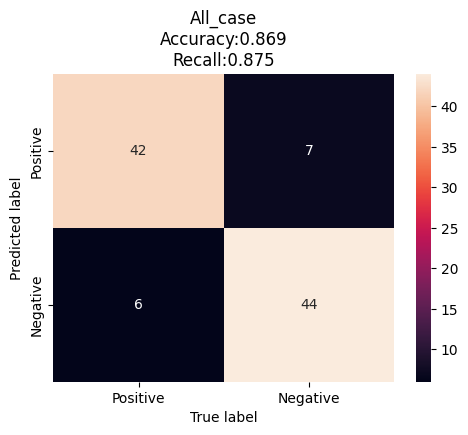

In [41]:
TP=len(LC_LC_class)
TN=len(AP_AP_class)
FP=len(AP_LC_class)
FN=len(LC_AP_class)
cm=[[TP,FP],[FN,TN]]
acc=(TP+TN)/(TP+TN+FP+FN)
recall=(TP)/(TP+FN)
cm_df = pd.DataFrame(cm,
                         index = ['Positive', 'Negative'], 
                         columns = ['Positive', 'Negative'])

plt.figure(figsize=(5.5,4))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.title("All_case" + '\nAccuracy:{0:.3f}\nRecall:{1:.3f}'.format(acc, recall))
plt.ylabel('Predicted label')
plt.xlabel('True label')
plt.show()

In [98]:
print(len(AP_time))
print(len(LC_time))

51
48


In [99]:
print(AP_time)

[4.074357032775879, 3.6721508502960205, 3.0945074558258057, 4.328425407409668, 3.2545924186706543, 3.324113130569458, 3.370854139328003, 3.7387287616729736, 3.5555217266082764, 3.5091915130615234, 4.057298183441162, 3.3559629917144775, 4.376627206802368, 4.194364070892334, 3.6917431354522705, 3.82080078125, 3.0948188304901123, 3.4647703170776367, 3.946550130844116, 3.922809600830078, 3.5494773387908936, 3.4144721031188965, 3.519575357437134, 3.3367326259613037, 3.6191792488098145, 3.666518211364746, 3.300593614578247, 4.256423473358154, 4.015438556671143, 3.578108787536621, 3.7181529998779297, 3.8014416694641113, 3.949474573135376, 3.96179461479187, 4.023672580718994, 3.7022857666015625, 4.033260822296143, 3.442758321762085, 3.535860538482666, 4.150357007980347, 3.9486958980560303, 3.6004323959350586, 4.050532817840576, 3.596679449081421, 3.515944004058838, 3.0539140701293945, 3.6271591186523438, 3.3771698474884033, 3.690568208694458, 4.0159032344818115, 4.1289660930633545]


In [23]:
print(LC_time)

[3.580249309539795, 3.843928813934326, 4.346867799758911, 3.1599485874176025, 3.450498580932617, 3.745251417160034, 3.3719515800476074, 4.338593244552612, 4.338702201843262, 3.619900941848755, 3.248267650604248, 3.271244525909424, 3.657358169555664, 3.7544639110565186, 4.146197319030762, 3.5471739768981934, 3.4070162773132324, 3.6791326999664307, 3.4661545753479004, 3.5936214923858643, 3.938019275665283, 2.772026538848877, 3.6102120876312256, 3.873507261276245, 3.2666447162628174, 4.357783794403076, 4.623629331588745, 3.1576008796691895, 3.743985176086426, 3.311941385269165, 4.415659189224243, 3.811798572540283, 3.3883845806121826, 3.813796043395996, 4.108616352081299, 3.9065818786621094, 3.804884672164917, 5.726996898651123, 5.41462254524231, 3.351010322570801, 3.3821234703063965, 3.2131712436676025, 3.1722238063812256, 4.042908191680908, 3.4701898097991943, 3.9083306789398193, 3.8109312057495117, 3.6901166439056396]


# 時間計算

In [32]:
A=[]
A=AP_time+LC_time
len(A)

99

In [34]:


# 计算平均时间
average_time = sum(A) / len(A)

print(f"平均时间是：{average_time} 秒")
print(max(A))
print(min(A))

平均时间是：3.5896766980489097 秒
5.726996898651123
2.772026538848877


In [79]:
# 将二值图像展平
case=["1760107","2133813","2370624","2396949"]
acc=[]
precision=[]
iou=[]
f1=[]
kernel1 = np.ones((5, 5), np.uint8)
for i in case:
    test_list_dir="./segment/{}/CY_AP_512x512".format(i)
    dir1=os.path.join(test_list_dir,"mask")
    dir2=os.path.join(test_list_dir,"segment")
    filelist=os.listdir(dir1)
    for name in filelist:
        pred_masks=cv2.imread(os.path.join(dir1, name))
        pred_masks = cv2.erode(pred_masks, kernel1)
        true_masks=cv2.imread(os.path.join(dir2, "mask"+name[-6:]))
        ret, pred_masks = cv2.threshold(pred_masks, 200, 255, cv2.THRESH_BINARY)
        ret, true_masks = cv2.threshold(true_masks, 200, 255, cv2.THRESH_BINARY)
        pred_masks=pred_masks/255
        true_masks=true_masks/255
        pred_masks_flat = pred_masks.flatten()
        true_masks_flat = true_masks.flatten()
        accuracy = accuracy_score(true_masks_flat, pred_masks_flat)
        f1_s = f1_score(true_masks_flat, pred_masks_flat)
        precision_s = precision_score(true_masks_flat, pred_masks_flat)
        iou_s = jaccard_score(true_masks_flat, pred_masks_flat)
        acc.append(accuracy)
        precision.append(precision_s)
        f1.append(f1_s)
        iou.append(iou_s)
# 计算各项指标
#
#precision = precision_score(true_masks_flat, pred_masks_flat)
#recall = recall_score(true_masks_flat, pred_masks_flat)
#
#

In [66]:
acc

[0.9973487854003906,
 0.9972724914550781,
 0.9970436096191406,
 0.9936027526855469,
 0.9883842468261719,
 0.9870147705078125,
 0.9812355041503906,
 0.9916267395019531,
 0.982147216796875,
 0.9956283569335938,
 0.9979400634765625,
 0.996612548828125,
 0.9963264465332031,
 0.9962921142578125,
 0.9968833923339844,
 0.9968452453613281,
 0.9968528747558594,
 0.9956245422363281,
 0.9921875,
 0.994720458984375,
 0.9943923950195312,
 0.9942512512207031,
 0.9902763366699219,
 0.9972305297851562,
 0.9974021911621094,
 0.9979972839355469,
 0.9977798461914062]

In [67]:
f1

[0.912058711881564,
 0.9394221808014911,
 0.9449847377014268,
 0.8881328797278366,
 0.8090549946698438,
 0.7679934569247545,
 0.618829910887253,
 0.8052178542905315,
 0.506953223767383,
 0.7161961367013373,
 0.8962336664104534,
 0.8393632416787266,
 0.836807320793086,
 0.8125000000000001,
 0.7998039696152904,
 0.905926515754749,
 0.9185185185185184,
 0.897139270020626,
 0.8240247465200207,
 0.8911264946507237,
 0.872903337368148,
 0.8617050564375516,
 0.690241827682586,
 0.8182273410115172,
 0.886329494241362,
 0.9014824544942768,
 0.8482794577685089]

In [68]:
iou

[0.8383344963945103,
 0.8857644991212654,
 0.8957071726550935,
 0.798776097912167,
 0.6793386689132266,
 0.6233680017703032,
 0.4480475763016158,
 0.6739453357100416,
 0.33954276037256564,
 0.5578703703703703,
 0.8119777158774373,
 0.7231920199501247,
 0.7194055944055944,
 0.6842105263157895,
 0.666394446712944,
 0.8280307756290289,
 0.8493150684931506,
 0.8134656041632786,
 0.7007160602075113,
 0.8036322360953462,
 0.7744706965326787,
 0.7570138664946792,
 0.5269994433104472,
 0.6923728813559322,
 0.795863309352518,
 0.820635462931329,
 0.7365323675871435]

In [80]:
case=["1760107","2133813","2370624","2396949"]
acc_2=[]
precision2=[]
iou_2=[]
f1_2=[]
for i in case:
    print(i)
    test_list_dir="./segment/{}/CY_AP_512x512".format(i)
    dir1=os.path.join(test_list_dir,"model2/mask")
    
    dir2=os.path.join(test_list_dir,"segment")
    filelist=os.listdir(dir1)
    for name in filelist:
        pred_masks=cv2.imread(os.path.join(dir1, name))
        true_masks=cv2.imread(os.path.join(dir2, "mask"+name[-6:]))
        ret, pred_masks = cv2.threshold(pred_masks, 200, 255, cv2.THRESH_BINARY)
        ret, true_masks = cv2.threshold(true_masks, 200, 255, cv2.THRESH_BINARY)
        pred_masks=pred_masks/255
        true_masks=true_masks/255
        pred_masks_flat = pred_masks.flatten()
        true_masks_flat = true_masks.flatten()
        accuracy = accuracy_score(true_masks_flat, pred_masks_flat)
        f1_s = f1_score(true_masks_flat, pred_masks_flat)
        precision_s = precision_score(true_masks_flat, pred_masks_flat)
        iou_s = jaccard_score(true_masks_flat, pred_masks_flat)
        precision2.append(precision_s)
        acc_2.append(accuracy)
        f1_2.append(f1_s)
        iou_2.append(iou_s)

1760107
2133813
2370624
2396949


In [81]:
acc_2

[0.9944267272949219,
 0.9940109252929688,
 0.9945716857910156,
 0.9928474426269531,
 0.9921722412109375,
 0.9865684509277344,
 0.986907958984375,
 0.9953994750976562,
 0.9974632263183594,
 0.9927902221679688,
 0.9930648803710938,
 0.9916038513183594,
 0.9938774108886719,
 0.9932746887207031,
 0.9938240051269531,
 0.9941902160644531,
 0.9923858642578125,
 0.9920387268066406,
 0.9886970520019531,
 0.9920387268066406,
 0.9919967651367188,
 0.9915618896484375,
 0.9876174926757812,
 0.9944992065429688,
 0.9940834045410156,
 0.9956932067871094,
 0.996551513671875]

In [82]:
iou_2

[0.7094849870749652,
 0.7816411682892906,
 0.8253344789493064,
 0.7963284814251576,
 0.7932910244786945,
 0.6872168428533357,
 0.6321543408360129,
 0.820615796519411,
 0.8710240496508922,
 0.49747407604360544,
 0.5762237762237762,
 0.513160805131608,
 0.6061349693251534,
 0.5443266994055311,
 0.5045899632802937,
 0.726325247079964,
 0.7000751314800902,
 0.7072931276297335,
 0.6180716679556587,
 0.7317480719794345,
 0.7067784765897973,
 0.6796524257784214,
 0.4677816035415642,
 0.5337859683155513,
 0.6316789361196865,
 0.6789877736707421,
 0.6533742331288344]

In [86]:
print(len(iou_2))
print(len(iou))
a=0
b=0
for i in range(0,len(iou_2)):
    a=iou[i]+a
    b=iou_2[i]+b
print(a/len(iou_2))
print(b/len(iou_2))

27
27
0.7201823353680036
0.6664649675095006


In [87]:
print(len(f1))
print(len(f1_2))
a=0
b=0
for i in range(0,len(f1_2)):
    a=f1[i]+a
    b=f1_2[i]+b
print(a/len(iou_2))
print(b/len(iou_2))

27
27
0.8299798814933174
0.7946746309118377


In [88]:
print(len(precision))
print(len(precision2))
a=0
b=0
for i in range(0,len(precision2)):
    a=precision[i]+a
    b=precision2[i]+b
print(a/len(iou_2))
print(b/len(iou_2))

27
27
0.7867853611056836
0.6893701758800718


In [ ]:
precision